In [7]:
import tensorflow as tf 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
data = pd.read_csv("Dataset--Heart-Disease-Prediction-using-ANN.csv")

In [3]:
data.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
data.isnull().any()

age         False
sex         False
cp          False
trestbps    False
chol        False
fbs         False
restecg     False
thalach     False
exang       False
oldpeak     False
slope       False
ca          False
thal        False
target      False
dtype: bool

In [5]:
X= data.iloc[:,:13].values
y = data["target"].values


In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 0 )

In [8]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
classifier = Sequential()
classifier.add(Dense(activation = "relu", input_dim = 13, units = 8, kernel_initializer = "uniform"))
classifier.add(Dense(activation = "relu",units = 14,kernel_initializer="uniform"))
classifier.add(Dense(activation="sigmoid", units = 1,kernel_initializer = "uniform"))
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy',metrics = ['accuracy'])


In [13]:
classifier.fit(X_train,y_train, batch_size = 8, epochs = 100)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5236 - loss: 0.6927   
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5660 - loss: 0.6897 
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7642 - loss: 0.6767 
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8443 - loss: 0.6404 
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8491 - loss: 0.5755 
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8585 - loss: 0.4955 
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8679 - loss: 0.4264 
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8726 - loss: 0.3820 
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8679 - loss: 0.3593 
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8726 - loss: 0.3426 
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8679 - loss: 0.3357 
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

<Axes: >

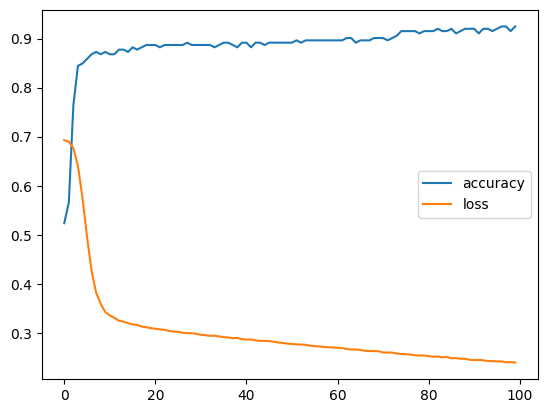

In [17]:
model_losses = pd.DataFrame(classifier.history.history)
model_losses.plot()

In [14]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [15]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[33, 11],
       [ 5, 42]])

In [16]:
accuracy = (cm[0][0]+cm[1][1]/cm[0][1] + cm[1][0]+cm[0][0]+ cm[1][1])
print(accuracy*100)

11681.818181818182
